In [1]:
import sys

te_path = "/home/kainingz/GitHub/TransformerEngine"

# Add it to the system path if it's not already there
if te_path not in sys.path:
    sys.path.append(te_path)

In [2]:
import os
import torch
import triton
import triton.language as tl
import triton.testing

# ---------------------------------------------------------------------------
# Import Triton ops (always available)
# ---------------------------------------------------------------------------
from transformer_engine.pytorch.triton.mhc import (
    mHCSinkhornOp,
    mHCPreOp,
    mHCPostResOp,
    mHCProjectionOp,
)

from native_kernels import (
    mHCProjectionRef,
    mHCSinkhornRef,
    mHCPreRef,
    mHCPostResRef
)


# ---------------------------------------------------------------------------
# Import cuTile ops (only when cuda.tile is installed)
# ---------------------------------------------------------------------------
try:
    from cutile_kernels import (
        fused_sinkhorn,
        fused_h_aggregate,
        fused_h_post_bda,
        fused_proj_rms,
        is_cutile_available,
    )
    CUTILE_AVAILABLE = is_cutile_available()
except (ImportError, RuntimeError):
    CUTILE_AVAILABLE = False


In [3]:
# ---------------------------------------------------------------------------
# Global config
# ---------------------------------------------------------------------------
DEVICE = "cuda"
DTYPE  = torch.bfloat16
N      = 4              # hyper-connection width; Triton kernels hard-require n=4
N_SINKHORN_ITERS = 20

# B=1 always (only B*T matters; vary T to sweep sequence length)
B_FIXED = 1
C_FIXED = 8192   # per-stream hidden dim (total hidden = n*C = 16384)

# Sweep range for T across all benchmarks
T_VALS = [512, 1024, 2048, 4096, 8192, 16384]

# Projection output features: 2n + n^2  with n=4  => 24
N_PROJ = 2 * N + N * N

# ---------------------------------------------------------------------------
# Helper: build line_vals / line_names / styles based on availability
# ---------------------------------------------------------------------------
def _lines():
    vals  = ["triton"] + (["cutile"] if CUTILE_AVAILABLE else [])
    names = ["Triton"] + (["cuTile"] if CUTILE_AVAILABLE else [])
    stys  = [("blue", "-")] + ([("red", "-")] if CUTILE_AVAILABLE else [])
    return vals, names, stys

_lv, _ln, _ls = _lines()

In [4]:
@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=["T"],
        x_vals=T_VALS,
        line_arg="provider",
        line_vals=_lv,
        line_names=_ln,
        styles=_ls,
        ylabel="Time (ms)",
        xlabel="T (sequence length)",
        plot_name=f"Sinkhorn_Forward_[B={B_FIXED}_n={N}_iters={N_SINKHORN_ITERS}]",
        args={},
    )
)
def bench_sinkhorn_fwd(T, provider):
    H_res = torch.randn(B_FIXED, T, N, N, dtype=DTYPE, device=DEVICE)

    if provider == "triton":
        fn = lambda: mHCSinkhornOp.apply(H_res, N, True, N_SINKHORN_ITERS)
    else:
        fn = lambda: fused_sinkhorn(H_res, num_iterations=N_SINKHORN_ITERS, eps=1e-6)

    return triton.testing.do_bench(fn)

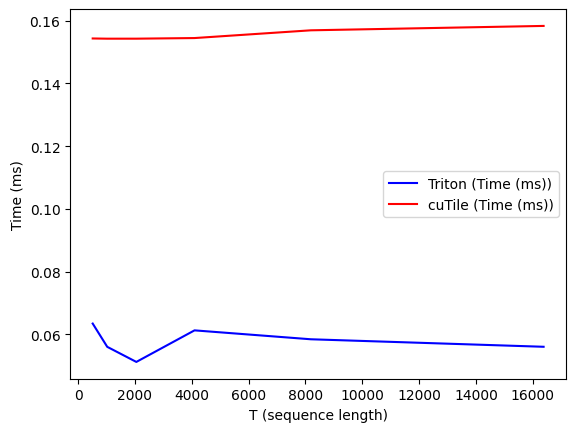

Sinkhorn_Forward_[B=1_n=4_iters=20]:
         T  Triton (Time (ms))  cuTile (Time (ms))
0    512.0            0.063456            0.154355
1   1024.0            0.056035            0.154287
2   2048.0            0.051225            0.154291
3   4096.0            0.061287            0.154486
4   8192.0            0.058446            0.156957
5  16384.0            0.056054            0.158356


In [5]:
bench_sinkhorn_fwd.run(print_data=True, show_plots=True)

In [6]:
@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=["T"],
        x_vals=T_VALS,
        line_arg="provider",
        line_vals=_lv,
        line_names=_ln,
        styles=_ls,
        ylabel="Time (ms)",
        xlabel="T (sequence length)",
        plot_name=f"Sinkhorn_Backward_[B={B_FIXED}_n={N}_iters={N_SINKHORN_ITERS}]",
        args={},
    )
)
def bench_sinkhorn_bwd(T, provider):
    H_res = torch.randn(B_FIXED, T, N, N, dtype=DTYPE, device=DEVICE, requires_grad=True)

    if provider == "triton":
        out = mHCSinkhornOp.apply(H_res, N, True, N_SINKHORN_ITERS)
    else:
        out = fused_sinkhorn(H_res, num_iterations=N_SINKHORN_ITERS, eps=1e-6)

    loss = out.sum()
    fn   = lambda: loss.backward(retain_graph=True)
    return triton.testing.do_bench(fn)


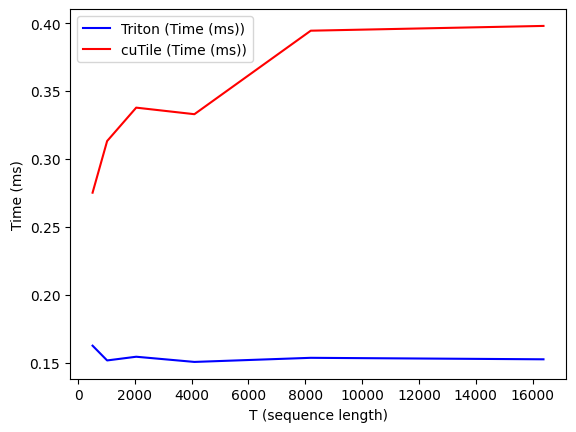

Sinkhorn_Backward_[B=1_n=4_iters=20]:
         T  Triton (Time (ms))  cuTile (Time (ms))
0    512.0            0.162690            0.275248
1   1024.0            0.151830            0.313241
2   2048.0            0.154554            0.337830
3   4096.0            0.150738            0.333006
4   8192.0            0.153758            0.394444
5  16384.0            0.152663            0.397956


In [7]:
bench_sinkhorn_bwd.run(print_data=True, show_plots=True)

In [8]:
@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=["T"],
        x_vals=T_VALS,
        line_arg="provider",
        line_vals=_lv,
        line_names=_ln,
        styles=_ls,
        ylabel="Time (ms)",
        xlabel="T (sequence length)",
        plot_name=f"HAggregate_PreOp_Forward_[B={B_FIXED}_C={C_FIXED}_n={N}]",
        args={},
    )
)
def bench_pre_fwd(T, provider):
    x_BTnC     = torch.randn(B_FIXED, T, N, C_FIXED, dtype=DTYPE, device=DEVICE)
    x_BTCn     = torch.randn(B_FIXED, T, C_FIXED, N, dtype=DTYPE, device=DEVICE)
    h_pre = torch.randn(B_FIXED, T, N,           dtype=DTYPE, device=DEVICE)

    if provider == "triton":
        fn = lambda: mHCPreOp.apply(x_BTCn, h_pre, N)
    elif provider == "cutile":
        fn = lambda: fused_h_aggregate(x_BTnC, h_pre)


    return triton.testing.do_bench(fn)

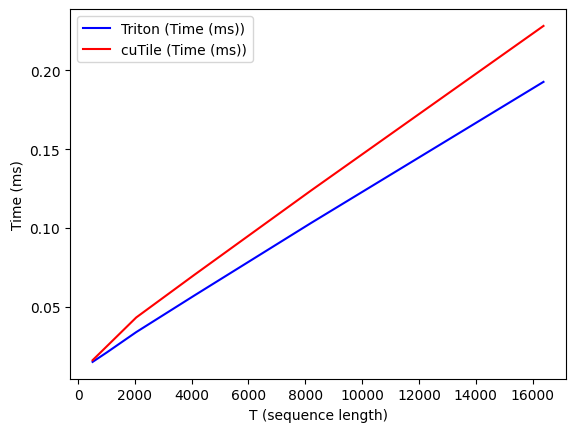

HAggregate_PreOp_Forward_[B=1_C=8192_n=4]:
         T  Triton (Time (ms))  cuTile (Time (ms))
0    512.0            0.015257            0.016329
1   1024.0            0.021397            0.025340
2   2048.0            0.034129            0.043395
3   4096.0            0.057334            0.070411
4   8192.0            0.103112            0.123651
5  16384.0            0.192592            0.228016


In [9]:
bench_pre_fwd.run(print_data=True, show_plots=True)

In [10]:
@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=["T"],
        x_vals=T_VALS,
        line_arg="provider",
        line_vals=_lv,
        line_names=_ln,
        styles=_ls,
        ylabel="Time (ms)",
        xlabel="T (sequence length)",
        plot_name=f"HAggregate_PreOp_Backward_[B={B_FIXED}_C={C_FIXED}_n={N}]",
        args={},
    )
)
def bench_pre_bwd(T, provider):
    x_BTnC     = torch.randn(B_FIXED, T, N, C_FIXED, dtype=DTYPE, device=DEVICE)
    x_BTCn     = torch.randn(B_FIXED, T, C_FIXED, N, dtype=DTYPE, device=DEVICE)
    h_pre = torch.randn(B_FIXED, T, N,           dtype=DTYPE, device=DEVICE, requires_grad=True)

    if provider == "triton":
        out = mHCPreOp.apply(x_BTCn, h_pre, N)
    else:
        out = fused_h_aggregate(x_BTnC, h_pre)

    loss = out.sum()
    fn   = lambda: loss.backward(retain_graph=True)
    return triton.testing.do_bench(fn)


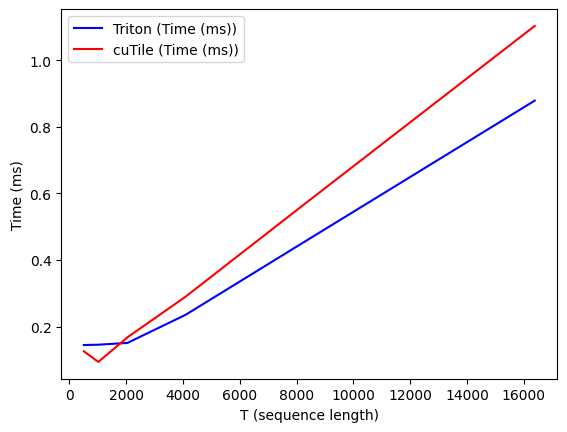

HAggregate_PreOp_Backward_[B=1_C=8192_n=4]:
         T  Triton (Time (ms))  cuTile (Time (ms))
0    512.0            0.144535            0.125832
1   1024.0            0.145656            0.093884
2   2048.0            0.150987            0.167881
3   4096.0            0.235488            0.290008
4   8192.0            0.450234            0.562304
5  16384.0            0.878901            1.103349


In [11]:
bench_pre_bwd.run(print_data=True, show_plots=True)

In [8]:
@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=["T"],
        x_vals=T_VALS,
        line_arg="provider",
        line_vals=_lv,
        line_names=_ln,
        styles=_ls,
        ylabel="Time (ms)",
        xlabel="T (sequence length)",
        plot_name=f"HPostBDA_PostResOp_Forward_[B={B_FIXED}_C={C_FIXED}_n={N}_bias=None]",
        args={},
    )
)
def bench_post_fwd_no_bias(T, provider):
    f      = torch.randn(B_FIXED, T,    C_FIXED, dtype=DTYPE, device=DEVICE)
    bias   = None
    H_post = torch.randn(B_FIXED, T, N,           dtype=DTYPE, device=DEVICE)
    x_BTnC = torch.randn(B_FIXED, T, N, C_FIXED,  dtype=DTYPE, device=DEVICE)
    H_res  = torch.randn(B_FIXED, T, N, N,         dtype=DTYPE, device=DEVICE)
    x_BTCn = torch.randn(B_FIXED, T, C_FIXED, N,  dtype=DTYPE, device=DEVICE)

    if provider == "triton":
        fn = lambda: mHCPostResOp.apply(f, bias, H_post, x_BTCn, H_res, N)
    else:
        # cuTile arg order: h_res, original_residual, h_post, x(=f), bias
        fn = lambda: fused_h_post_bda(H_res, x_BTnC, H_post, f, bias)

    return triton.testing.do_bench(fn)

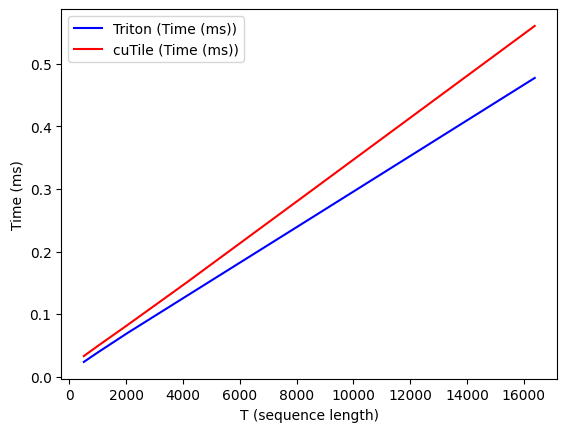

HPostBDA_PostResOp_Forward_[B=1_C=8192_n=4_bias=None]:
         T  Triton (Time (ms))  cuTile (Time (ms))
0    512.0            0.023564            0.032926
1   1024.0            0.039320            0.049717
2   2048.0            0.069733            0.082484
3   4096.0            0.127958            0.149309
4   8192.0            0.244278            0.286142
5  16384.0            0.477384            0.560493


In [9]:
bench_post_fwd_no_bias.run(print_data=True, show_plots=True)

In [10]:
@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=["T"],
        x_vals=T_VALS,
        line_arg="provider",
        line_vals=_lv,
        line_names=_ln,
        styles=_ls,
        ylabel="Time (ms)",
        xlabel="T (sequence length)",
        plot_name=f"HPostBDA_PostResOp_Backward_[B={B_FIXED}_C={C_FIXED}_n={N}_bias=None]",
        args={},
    )
)
def bench_post_bwd_no_bias(T, provider):
    f      = torch.randn(B_FIXED, T,    C_FIXED, dtype=DTYPE, device=DEVICE, requires_grad=True)
    bias   = None
    H_post = torch.randn(B_FIXED, T, N,           dtype=DTYPE, device=DEVICE, requires_grad=True)
    x_BTnC      = torch.randn(B_FIXED, T, N, C_FIXED,  dtype=DTYPE, device=DEVICE, requires_grad=True)
    x_BTCn      = torch.randn(B_FIXED, T, C_FIXED, N,  dtype=DTYPE, device=DEVICE, requires_grad=True)
    H_res  = torch.randn(B_FIXED, T, N, N,         dtype=DTYPE, device=DEVICE, requires_grad=True)

    if provider == "triton":
        out = mHCPostResOp.apply(f, bias, H_post, x_BTCn, H_res, N)
    else:
        out = fused_h_post_bda(H_res, x_BTnC, H_post, f, bias)

    loss = out.sum()
    fn   = lambda: loss.backward(retain_graph=True)
    return triton.testing.do_bench(fn)

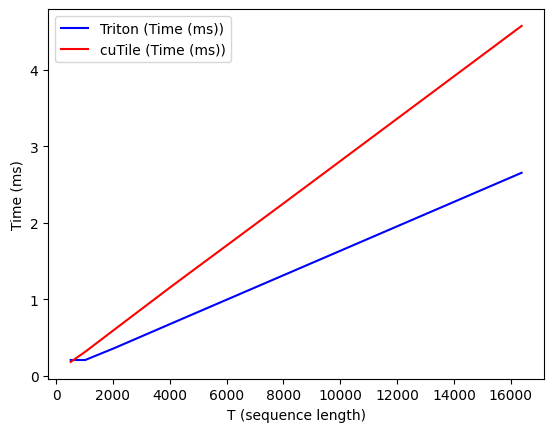

HPostBDA_PostResOp_Backward_[B=1_C=8192_n=4_bias=None]:
         T  Triton (Time (ms))  cuTile (Time (ms))
0    512.0            0.205528            0.180627
1   1024.0            0.205904            0.313441
2   2048.0            0.360766            0.602633
3   4096.0            0.689273            1.178006
4   8192.0            1.343550            2.304566
5  16384.0            2.651939            4.570726


In [11]:
bench_post_bwd_no_bias.run(print_data=True, show_plots=True)

In [4]:
@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=["T"],
        x_vals=T_VALS,
        line_arg="provider",
        line_vals=_lv,
        line_names=_ln,
        styles=_ls,
        ylabel="Time (ms)",
        xlabel="T (sequence length)",
        plot_name=f"HPostBDA_PostResOp_Forward_[B={B_FIXED}_C={C_FIXED}_n={N}_bias=None]",
        args={},
    )
)
def bench_post_fwd(T, provider):
    f      = torch.randn(B_FIXED, T,    C_FIXED, dtype=DTYPE, device=DEVICE)
    bias   = torch.randn(C_FIXED, dtype=DTYPE, device=DEVICE)
    H_post = torch.randn(B_FIXED, T, N,           dtype=DTYPE, device=DEVICE)
    x_BTnC = torch.randn(B_FIXED, T, N, C_FIXED,  dtype=DTYPE, device=DEVICE)
    H_res  = torch.randn(B_FIXED, T, N, N,         dtype=DTYPE, device=DEVICE)
    x_BTCn = torch.randn(B_FIXED, T, C_FIXED, N,  dtype=DTYPE, device=DEVICE)

    if provider == "triton":
        fn = lambda: mHCPostResOp.apply(f, bias, H_post, x_BTCn, H_res, N)
    else:
        # cuTile arg order: h_res, original_residual, h_post, x(=f), bias
        fn = lambda: fused_h_post_bda(H_res, x_BTnC, H_post, f, bias)

    return triton.testing.do_bench(fn)

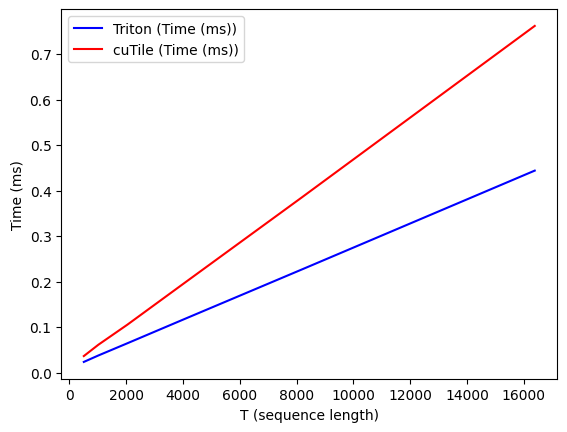

HPostBDA_PostResOp_Forward_[B=1_C=8192_n=4_bias=None]:
         T  Triton (Time (ms))  cuTile (Time (ms))
0    512.0            0.023357            0.036240
1   1024.0            0.037539            0.061134
2   2048.0            0.064439            0.105367
3   4096.0            0.118702            0.198790
4   8192.0            0.226681            0.385235
5  16384.0            0.443810            0.761813


In [5]:
bench_post_fwd.run(print_data=True, show_plots=True)

In [6]:
@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=["T"],
        x_vals=T_VALS,
        line_arg="provider",
        line_vals=_lv,
        line_names=_ln,
        styles=_ls,
        ylabel="Time (ms)",
        xlabel="T (sequence length)",
        plot_name=f"HPostBDA_PostResOp_Backward_[B={B_FIXED}_C={C_FIXED}_n={N}_bias=None]",
        args={},
    )
)
def bench_post_bwd(T, provider):
    f      = torch.randn(B_FIXED, T,    C_FIXED, dtype=DTYPE, device=DEVICE, requires_grad=True)
    bias   = torch.randn(C_FIXED, dtype=DTYPE, device=DEVICE)
    H_post = torch.randn(B_FIXED, T, N,           dtype=DTYPE, device=DEVICE, requires_grad=True)
    x_BTnC      = torch.randn(B_FIXED, T, N, C_FIXED,  dtype=DTYPE, device=DEVICE, requires_grad=True)
    x_BTCn      = torch.randn(B_FIXED, T, C_FIXED, N,  dtype=DTYPE, device=DEVICE, requires_grad=True)
    H_res  = torch.randn(B_FIXED, T, N, N,         dtype=DTYPE, device=DEVICE, requires_grad=True)

    if provider == "triton":
        out = mHCPostResOp.apply(f, bias, H_post, x_BTCn, H_res, N)
    else:
        out = fused_h_post_bda(H_res, x_BTnC, H_post, f, bias)

    loss = out.sum()
    fn   = lambda: loss.backward(retain_graph=True)
    return triton.testing.do_bench(fn)

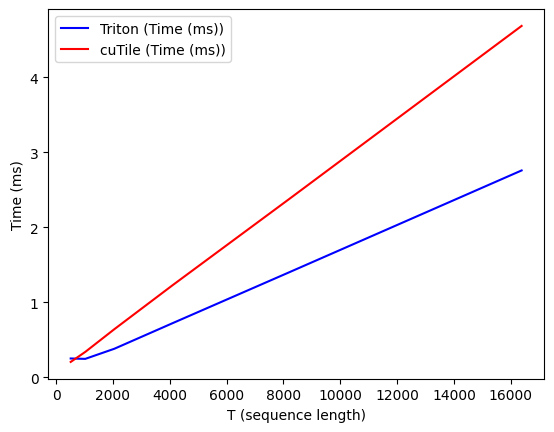

HPostBDA_PostResOp_Backward_[B=1_C=8192_n=4_bias=None]:
         T  Triton (Time (ms))  cuTile (Time (ms))
0    512.0            0.248864            0.202904
1   1024.0            0.243545            0.336141
2   2048.0            0.378547            0.639595
3   4096.0            0.719539            1.225781
4   8192.0            1.397108            2.373538
5  16384.0            2.757878            4.686376


In [7]:
bench_post_bwd.run(print_data=True, show_plots=True)

In [16]:
@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=["T"],
        x_vals=T_VALS,
        line_arg="provider",
        line_vals=_lv,
        line_names=_ln,
        styles=_ls,
        ylabel="Time (ms)",
        xlabel="T (sequence length)",
        plot_name=(
            f"ProjRms_ProjectionOp_Forward_[B={B_FIXED}_C={C_FIXED}_n={N}_N_proj={N_PROJ}]"
        ),
        args={},
    )
)
def bench_proj_fwd(T, provider):
    M   = B_FIXED * T
    K   = N * C_FIXED  # total hidden dimension
    x   = torch.randn(M, K,      dtype=DTYPE, device=DEVICE)
    phi = torch.randn(N_PROJ, K, dtype=DTYPE, device=DEVICE)

    if provider == "triton":
        fn = lambda: mHCProjectionOp.apply(x, phi)
    else:
        fn = lambda: fused_proj_rms(x, phi)

    return triton.testing.do_bench(fn)

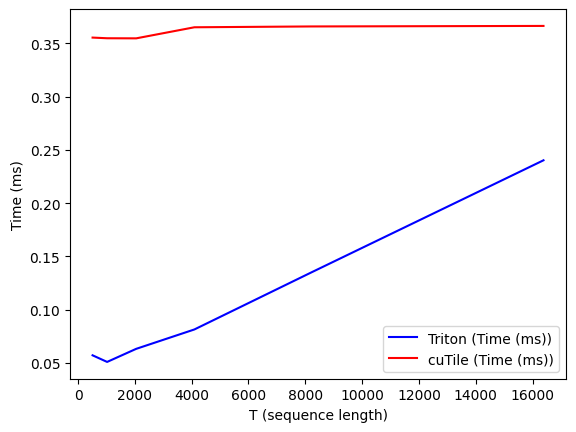

ProjRms_ProjectionOp_Forward_[B=1_C=8192_n=4_N_proj=24]:
         T  Triton (Time (ms))  cuTile (Time (ms))
0    512.0            0.057243            0.355379
1   1024.0            0.051038            0.354752
2   2048.0            0.063315            0.354660
3   4096.0            0.081501            0.365052
4   8192.0            0.134762            0.365826
5  16384.0            0.240237            0.366322


In [17]:
bench_proj_fwd.run(print_data=True, show_plots=True)

In [4]:
@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=["T"],
        x_vals=T_VALS,
        line_arg="provider",
        line_vals=_lv,
        line_names=_ln,
        styles=_ls,
        ylabel="Time (ms)",
        xlabel="T (sequence length)",
        plot_name=(
            f"ProjRms_ProjectionOp_Backward_[B={B_FIXED}_C={C_FIXED}_n={N}_N_proj={N_PROJ}]"
        ),
        args={},
    )
)
def bench_proj_bwd(T, provider):
    M   = B_FIXED * T
    K   = N * C_FIXED
    x   = torch.randn(M, K,      dtype=DTYPE, device=DEVICE, requires_grad=True)
    phi = torch.randn(N_PROJ, K, dtype=DTYPE, device=DEVICE, requires_grad=True)

    if provider == "triton":
        H, r = mHCProjectionOp.apply(x, phi)
        loss = H.sum() + r.sum()
    else:
        proj, r = fused_proj_rms(x, phi)
        loss = proj.sum() + r.sum()

    fn = lambda: loss.backward(retain_graph=True)
    return triton.testing.do_bench(fn)

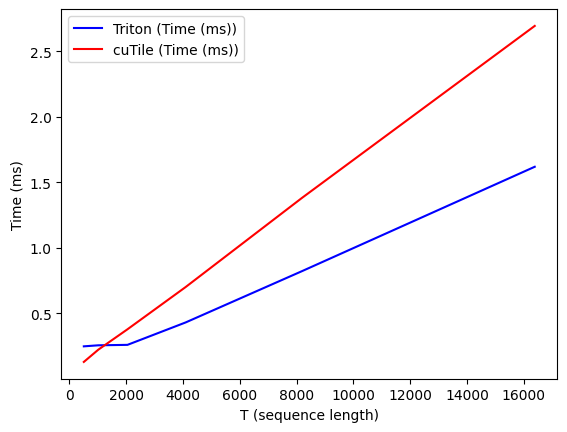

ProjRms_ProjectionOp_Backward_[B=1_C=8192_n=4_N_proj=24]:
         T  Triton (Time (ms))  cuTile (Time (ms))
0    512.0            0.249068            0.130272
1   1024.0            0.256992            0.223969
2   2048.0            0.260373            0.379022
3   4096.0            0.431306            0.701241
4   8192.0            0.822434            1.381021
5  16384.0            1.618233            2.692156


In [5]:
bench_proj_bwd.run(print_data=True, show_plots=True)